[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RlNZLER/Reinforcement-Learning/blob/main/minor_projects/chapter-2-bandit/10-armed-bandit.ipynb)



# 10-Armed Bandit — Multiple ε-Greedy Algorithms

This notebook compares three ε-greedy strategies on the 10-armed testbed (Sutton & Barto):
**ε = 0.0**, **ε = 0.1**, **ε = 0.01**.

For speed here we use `N_RUNS = 200`. To reproduce the book's setup exactly, set `N_RUNS = 2000`.


## Design

In each run:

1. Draw true values \( q^*(a) \sim \mathcal{N}(0,1) \) for 10 actions.
2. For 1000 steps: select using ε-greedy, observe \( R_t \sim \mathcal{N}(q^*(A_t), 1) \), update \( Q \) via sample average.

We average across runs to plot **Average Reward** and **% Optimal Action** over time.


In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
N_ACTIONS = 10
N_STEPS = 1000
N_RUNS = 2000        # set to 2000 for the book
EPSILONS = [0.0, 0.1, 0.01]

In [14]:
def select_action(Q, epsilon, rng):
    if rng.random() < epsilon:
        return rng.integers(len(Q))
    max_value = np.max(Q)
    candidates = np.flatnonzero(np.isclose(Q, max_value))
    if candidates.size == 0:
        candidates = np.array([int(np.argmax(Q))])
    return rng.choice(candidates)

def simulate_bandit(epsilon, n_actions=N_ACTIONS, n_steps=N_STEPS, n_runs=N_RUNS, seed=0):
    rng = np.random.default_rng(seed)
    avg_rewards = np.zeros(n_steps)
    optimal_action_counts = np.zeros(n_steps)

    for run in range(n_runs):
        q_true = rng.normal(0.0, 1.0, size=n_actions)
        optimal_action = int(np.argmax(q_true))

        Q = np.zeros(n_actions)
        N = np.zeros(n_actions, dtype=int)

        for t in range(n_steps):
            a = select_action(Q, epsilon, rng)
            r = rng.normal(q_true[a], 1.0)

            N[a] += 1
            Q[a] += (r - Q[a]) / N[a]

            avg_rewards[t] += r
            if a == optimal_action:
                optimal_action_counts[t] += 1

    avg_rewards /= n_runs
    optimal_pct = (optimal_action_counts / n_runs) * 100.0
    return avg_rewards, optimal_pct


In [15]:
results = {}
for eps in EPSILONS:
    avg_rewards, optimal_pct = simulate_bandit(eps)
    results[eps] = {"avg_rewards": avg_rewards, "optimal_pct": optimal_pct}


### Plot: Average Reward

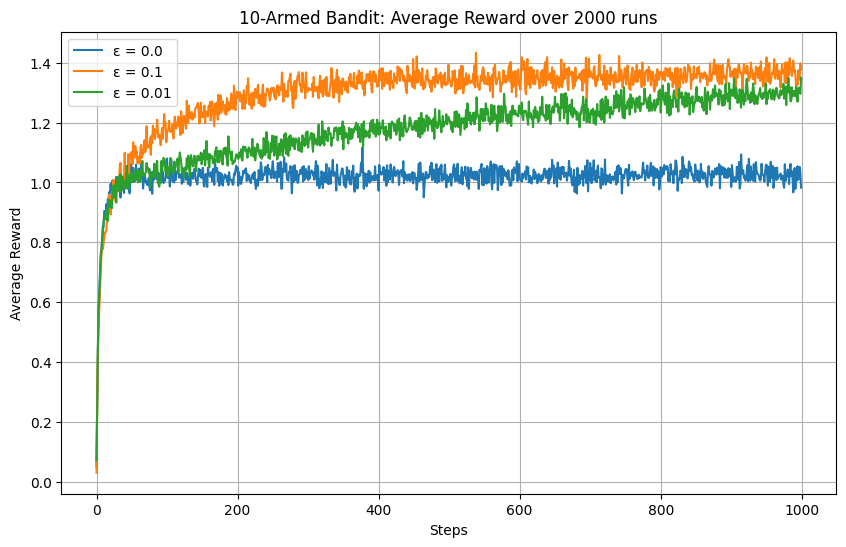

In [16]:
plt.figure(figsize=(10, 6))
for eps in EPSILONS:
    plt.plot(results[eps]["avg_rewards"], label=f"ε = {eps}")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title(f"10-Armed Bandit: Average Reward over {N_RUNS} runs")
plt.grid(True)
plt.legend()
plt.show()


### Plot: % Optimal Action

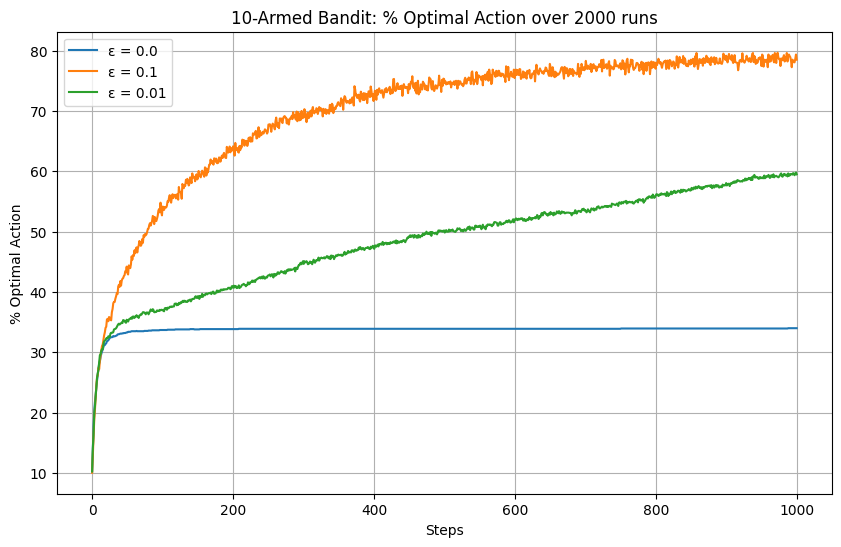

In [17]:
plt.figure(figsize=(10, 6))
for eps in EPSILONS:
    plt.plot(results[eps]["optimal_pct"], label=f"ε = {eps}")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title(f"10-Armed Bandit: % Optimal Action over {N_RUNS} runs")
plt.grid(True)
plt.legend()
plt.show()


## Notes

- Greedy (ε=0) can get stuck due to early noise.
- ε=0.1 typically wins in long-run reward by balancing exploration/exploitation.
- ε=0.01 explores less; curves sit between ε=0 and ε=0.1.